Neural networks have exploded in popularity in almost every data format, from images and videos to text. One data format where they are yet to make in-roads is tabular data. For tabular data, the most popular algorithms continue to be tree-based boosting algorithms such as [XGBoost](https://en.wikipedia.org/wiki/XGBoost), [LighGBM](https://en.wikipedia.org/wiki/LightGBM) and [CatBoost](https://en.wikipedia.org/wiki/Catboost), or even simple linear algorithms like [Linear](https://en.wikipedia.org/wiki/Linear_regression)/[Logistic](https://en.wikipedia.org/wiki/Logistic_regression) Regression.

TabNet<sup>[\[1\]](#ref1)</sup> is a remedy to this. It is an attention-based neural network introduced in 2019 by a Google Cloud AI team. It beats XGBoost, LightGBM and CatBoost on multiple datasets such as [Forest Cover Type](https://archive.ics.uci.edu/ml/datasets/covertype) and [Poker Hand](https://archive.ics.uci.edu/ml/datasets/Poker+Hand). It also tends to be more explainable than these other algorithms.

In this notebook, we will use TabNet to solve the [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic) competition. We will use the [TabNet implementation for PyTorch by Dreamquark](https://github.com/dreamquark-ai/tabnet) in order to do this. We will also use [Optuna](https://github.com/optuna/optuna) to tune the hyperparameters of the model.


> Note: For more on TabNet, refer to this video by the co-author of the above mentioned library: [Talks # 4: Sebastien Fischman - Pytorch-TabNet: Beating XGBoost on Tabular Data Using Deep Learning](https://www.youtube.com/watch?v=ysBaZO8YmX8).

In [1]:
# Install TabNet
!pip install pytorch-tabnet

# TabNet Architecture

Architecturally, TabNet consists of multiple encoder steps, as shown below:

![](https://drive.google.com/uc?export=view&id=1fM0jdeUB7pgj_Zg1z7jwmeM7ATZzWMF6)

Intuitively, each step selects a subset of features from all the features available in the training data to use for its predictions. How it differs from most other neural networks is that this selection step occurs for each sample instead of the entire training data. Thus, the predictions for each sample are generated by different subset of features. This leads to better performance.

There are three main layers that make up a step.

### Feature Transformer

![TabNet Feature Transformer](https://drive.google.com/uc?export=view&id=1TSyJwEYjAN5CT5cdTLLaVbcmmXXaNpL6)

The feature transformer layer generates an internal representation of the features.

Each layer consists of stacks of a fully-connected layer, a batch normalisation and a [GLU](https://paperswithcode.com/method/glu) activation function, with skip connections in between stacks.

Some of the stacks are shared across all the steps and some stacks are local to a step. That is, the feature transformer in each step uses some weights that are common across every step and some weights that are learnt specifically for that step. This ensures that other steps have some information from every step while generating their internal representation.

Take note of the split block in the overall architecture. This block is used to split the internal representation between the next step (red arrow) and the overall output (blue arrow). Clearly, no such split is required in step $0$ and hence, there is only a red arrow.

### Attentive Transformer

![TabNet Attentive Transformer](https://drive.google.com/uc?export=view&id=17SAFPueqARehjkxD0UmRmLAXAT8c-DXx)

The attentive transformer layer takes the learned representation of features as input and outputs a mask which is then used to select the features that should be used for this step and the current sample. The mask can be thought of as consisting of probabilities that sum up to $1$.

Each layer consists of a fully-connected layer, a batch normalisation and a "sparse" softmax activation. The softmax activation is sparse since the generated mask has a lot of zeros in it, denoting that the features associated with those zeros are not used for generating predictions.

The prior scales shown in the diagram consists of information which denotes how much each feature has been used in the previous steps. This is taken into account while generating the mask. Mathematically, if the current step is $i$, $P[i]=\prod_{j=1}^{i}(\gamma-M[j])$, where $\gamma$ is a relaxation parameter and $M[j]$ is the mask in step $j$. When $\gamma=1$, a feature is enforced to be used only for one step (since then $\gamma-M[j]\approx0$) and as $\gamma$ increases, the constraint relaxes so that the feature can be used for multiple steps.

### Feature Masking

The feature masking layer uses the generated mask to select a subset of features. It is a element-wise product between the original features and the generated mask.

# Explainability

An important goal behind TabNet is to be explainable. This is achieved by using the generated masks in each step. Using the masks, it is possible to visualize which features are being used the most for each sample at each step.

# Imports

In [2]:
import functools
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn import metrics


warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
def seed_everything(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
seed_everything()

# Configuration

We will define a configuration class that will store some basic configuration that is used throughout the notebook.

In [4]:
class Config:
    DATA_DIR = "../input/spaceship-titanic-prepared-datasets"
    MAX_EPOCHS = 30
    N_TRIALS = 30
    PATIENCE = 20
    BATCH_SIZE = 1024
    NUM_WORKERS = 2
    
    DEFAULTS = {
        "n_d": 8,
        "n_a": 8,
        "n_steps": 3,
        "n_shared":  2,
        "cat_emb_dim": 1,
        "lr": 2e-2,
        "mask_type": "entmax",
        "lambda_sparse": 1e-3,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
    }
    
    @classmethod
    def filepath(cls, filename):
        return os.path.join(cls.DATA_DIR, filename)

# Load Datasets

> Note: This notebook uses the datasets as prepared in [Spaceship Titanic - Logistic Regression Baselines](https://www.kaggle.com/code/defcodeking/spaceship-titanic-logistic-regression-baselines). Link to dataset: [Spaceship Titanic Prepared Datasets](https://www.kaggle.com/datasets/defcodeking/spaceship-titanic-prepared-datasets).

We will load the datasets.

In [5]:
train_df = pd.read_csv(Config.filepath("train_prepared_both_le.csv"))
test_df = pd.read_csv(Config.filepath("test_prepared_both_le.csv"))

In [6]:
train_df.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Alone,RoomService_missing,...,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinNum,GroupId,Transported,kfold
0,0.0,0.702095,0.0,-0.337025,-0.284274,-0.287317,-0.273736,-0.266098,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,14,3271,0.0,0
1,0.0,-0.333233,0.0,-0.173528,-0.278689,-0.245971,0.209267,-0.227692,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,14,8087,1.0,3
2,0.0,2.013510,1.0,-0.272527,1.934922,-0.287317,5.634034,-0.223327,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,14,2127,0.0,4
3,0.0,0.287964,0.0,-0.337025,0.511931,0.326250,2.655075,-0.097634,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,14,2127,0.0,4
4,0.0,-0.885407,0.0,0.117466,-0.240833,-0.037590,0.223344,-0.264352,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,88,6590,1.0,4


In [7]:
test_df.head()

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Alone,...,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinNum,GroupId
0,0013_01,1.0,-0.116957,0.0,-0.361266,-0.287719,-0.316173,-0.271297,-0.249197,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,60,3144
1,0018_01,0.0,-0.681236,0.0,-0.361266,-0.281826,-0.316173,2.255891,-0.249197,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3,3118
2,0019_01,1.0,0.165182,0.0,-0.361266,-0.287719,-0.316173,-0.271297,-0.249197,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,14,3117
3,0021_01,0.0,0.658927,0.0,-0.361266,4.067167,-0.316173,-0.109263,0.219987,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,88,3116
4,0023_01,0.0,-0.610702,0.0,-0.344790,-0.287719,0.816230,-0.271297,-0.249197,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,77,3115


# Preprocessing

TabNet comes with suppoprt for categorical features out of the box. All we need to do is to make sure they are label encoded and have their datatype as integer. We will define a function which takes the training and test dataframes and label encodes all the one-hot encoded columns.

In [8]:
def preprocess_datasets(train_df, test_df):
    # Make copies so that original datasets remain unchanged
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # Drop Transported and kfold
    drop = ["Transported", "kfold"]
    dropped = train_df[drop].values
    train_df = train_df.drop(drop, axis=1)
    
    # Drop PassengerId
    passenger_id = test_df["PassengerId"].values
    test_df = test_df.drop("PassengerId", axis=1)
    
    # Add suffix to index and store indices
    # So that the dataframes can be merged and split
    train_df = train_df.rename("train_{}".format)
    test_df = test_df.rename("test_{}".format)
    
    tr_idx = train_df.index
    te_idx = test_df.index
    
    # Merge
    df = pd.concat([train_df, test_df])
    
    oh_cols = ["CabinDeck", "HomePlanet", "Destination", "GroupSize"]
    
    for oh_col in oh_cols:
        # Get all columns associated with the one-hot column
        columns = [column for column in df.columns if column.startswith(f"{oh_col}_")]
        
        # .idxmax() returns that column name which has the maximum value in the row
        values = df[columns].idxmax(axis=1)
        
        # Get all levels and make a mapping from level to index
        levels = values.value_counts().index
        mapping = {level: idx for idx, level in enumerate(levels)}
        
        # Add column with the mapping and specify type as int
        df[oh_col] = values.map(mapping).astype(int)
        
        # Drop one-hot columns
        df = df.drop(columns, axis=1)
        
    # Make sure other categorical features have the right type
    missing = (col for col in df.columns if col.endswith("_missing"))
    others = ["CryoSleep", "VIP", "Alone", "CabinNum", "GroupId", *missing]
    df[others] = df[others].astype(int)
        
    # Split and add dropped columns
    train_df = df.loc[tr_idx, :]
    train_df[drop] = dropped
    
    test_df = df.loc[te_idx, :]
    test_df["PassengerId"] = passenger_id
    
    return train_df, test_df

## Prepare Datasets

We will use the function above to prepare the datasets.

In [9]:
# Prepare datasets
train_df, test_df = preprocess_datasets(train_df, test_df)

In [10]:
train_df.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Alone,RoomService_missing,...,TotalExpense,CabinSide,CabinNum,GroupId,CabinDeck,HomePlanet,Destination,GroupSize,Transported,kfold
train_0,0,0.702095,0,-0.337025,-0.284274,-0.287317,-0.273736,-0.266098,1,0,...,-0.514066,1.0,14,3271,3,1,0,0,0.0,0.0
train_1,0,-0.333233,0,-0.173528,-0.278689,-0.245971,0.209267,-0.227692,1,0,...,-0.251479,0.0,14,8087,0,0,0,0,1.0,3.0
train_2,0,2.013510,1,-0.272527,1.934922,-0.287317,5.634034,-0.223327,0,0,...,3.190333,0.0,14,2127,6,1,0,1,0.0,4.0
train_3,0,0.287964,0,-0.337025,0.511931,0.326250,2.655075,-0.097634,0,0,...,1.332604,0.0,14,2127,6,1,0,1,0.0,4.0
train_4,0,-0.885407,0,0.117466,-0.240833,-0.037590,0.223344,-0.264352,1,0,...,-0.124824,0.0,88,6590,0,0,0,0,1.0,4.0


In [11]:
test_df.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Alone,RoomService_missing,...,TotalExpense_missing,TotalExpense,CabinSide,CabinNum,GroupId,CabinDeck,HomePlanet,Destination,GroupSize,PassengerId
test_0,1,-0.116957,0,-0.361266,-0.287719,-0.316173,-0.271297,-0.249197,1,0,...,0,-0.503425,0.0,60,3144,1,0,0,0,0013_01
test_1,0,-0.681236,0,-0.361266,-0.281826,-0.316173,2.255891,-0.249197,1,0,...,0,0.502231,0.0,3,3118,0,0,0,0,0018_01
test_2,1,0.165182,0,-0.361266,-0.287719,-0.316173,-0.271297,-0.249197,1,0,...,0,-0.503425,0.0,14,3117,4,1,1,0,0019_01
test_3,0,0.658927,0,-0.361266,4.067167,-0.316173,-0.109263,0.219987,1,0,...,0,2.130740,0.0,88,3116,4,1,0,0,0021_01
test_4,0,-0.610702,0,-0.344790,-0.287719,0.816230,-0.271297,-0.249197,1,0,...,0,-0.274383,0.0,77,3115,0,0,0,0,0023_01


## Define Some Parameters Required By TabNet

In order to correctly handle categorical features, TabNet requires two arguments:

- `cat_idxs`: This should be a list of positions of categorical features in terms of indices in the training data.
- `cat_dims`: This should be a list of the number of classes in each categorical features in the training data. It should have the same order as `cat_idxs`.

Thus, we will create these two lists.

In [12]:
cols = train_df.columns

# Create a list of all categorical columns in the dataframe
missing = (col for col in cols if col.endswith("_missing"))
categorical_features = [
    "CryoSleep",
    "VIP",
    "Alone",
    "CabinNum",
    "GroupId",
    "HomePlanet",
    "Destination",
    "CabinDeck",
    "GroupSize",
    "CabinSide",
    *missing
]

In [13]:
target = "Transported"
unused = ["kfold"]

# Create a list of all features
features = [col for col in cols if col not in unused + [target]]

# Find the indices of all categorical features
categorical_idx = [idx for idx, feature in enumerate(features) if feature in categorical_features]

# Get the number of classes of each categorical feature
# The concatenation is required since there are some categorical features
# With some levels present only in either train or test data
categorical_dims = [
    pd.concat([train_df[col], test_df[col]]).nunique() for col in cols if col in categorical_features
]


features, categorical_idx, categorical_dims

(['CryoSleep',
  'Age',
  'VIP',
  'RoomService',
  'FoodCourt',
  'ShoppingMall',
  'Spa',
  'VRDeck',
  'Alone',
  'RoomService_missing',
  'FoodCourt_missing',
  'ShoppingMall_missing',
  'Cabin_missing',
  'VIP_missing',
  'TotalExpense_missing',
  'TotalExpense',
  'CabinSide',
  'CabinNum',
  'GroupId',
  'CabinDeck',
  'HomePlanet',
  'Destination',
  'GroupSize'],
 [0, 2, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22],
 [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1894, 9280, 8, 3, 3, 8])

# Parameters For TabNet

The function below will be used to get the the initialization parameters for TabNet. Using a function this way allows us to easily integrate Optuna into the pipeline. Take note of the number of hyperparameters TabNet has. Out of these, only a few need to be tuned. This is also another benefit TabNet has over XGBoost and LightGBM, which have a relatively large number of hyperparameters.

Also take note of `device_name`. When set to `auto`, TabNet automatically detects a GPU and uses it if available.

In [14]:
TabNetClassifier()

Device used : cuda


TabNetClassifier(n_d=8, n_a=8, n_steps=3, gamma=1.3, cat_idxs=[], cat_dims=[], cat_emb_dim=1, n_independent=2, n_shared=2, epsilon=1e-15, momentum=0.02, lambda_sparse=0.001, seed=0, clip_value=1, verbose=1, optimizer_fn=<class 'torch.optim.adam.Adam'>, optimizer_params={'lr': 0.02}, scheduler_fn=None, scheduler_params={}, mask_type='sparsemax', input_dim=None, output_dim=None, device_name='auto')

In [15]:
def get_init_params(params, verbose=1, cat_idxs=None, cat_dims=None):
    return {
        "n_d": params.get("n_d", 8),
        "n_a": params.get("n_d", 8),
        "n_steps": params.get("n_steps", 3),
        "n_shared": params.get("n_shared", 2),
        "cat_emb_dim": params.get("cat_emb_dim", 1),
        "optimizer_params": {"lr": params.get("lr", 2e-2)},
        "mask_type": params.get("mask_type", "sparsemax"),
        "lambda_sparse": params.get("lambda_sparse", 1e-3),
        "optimizer_fn": torch.optim.Adam,
        "cat_idxs": cat_idxs or [],
        "cat_dims": cat_dims or [],
        "verbose": verbose,
    }

# Training Loop

We will define the training loop as a function.

It takes the training and test dataframes, parameters for training, a list of features to be used, name of the target in the dataframe, a verbosity argument, and optional categorical indices and dimensions as required by TabNet. At the end, it returns the test predictions, training history, the average best score and data that can be used for explainability.

> Note: TabNet automatically selects the epoch with the best score after `.fit()` for making predictions.

In [16]:
def train(
    train_df,
    test_df,
    params,
    features,
    target,
    verbose=1,
    cat_idxs=None,
    cat_dims=None
):
    # Variables to store test predictions, history and total best score
    test_preds, history, total_best_score = [], {}, 0.0
    
    # Variable to store the data required for explainability
    explains = {}
    
    for fold in range(5):
        print(f"Fold {fold + 1}:")
        
        # Get the training and validation sets
        train = train_df[train_df["kfold"] != fold]
        val = train_df[train_df["kfold"] == fold]
        
        # Get the training features and labels
        X_train = train[features].values
        y_train = train[target].values
        
        # Get the validation features and labels
        X_val = val[features].values
        y_val = val[target].values
        
        # Get the init parameters
        init_params = get_init_params(params, verbose=verbose, cat_idxs=cat_idxs, cat_dims=cat_dims)
        
        # Create model
        clf = TabNetClassifier(**init_params)
        
        # Train model
        clf.fit(
            X_train=X_train,
            y_train=y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_name=["train", "valid"],
            eval_metric=["accuracy"],
            max_epochs=params.get("max_epochs", Config.MAX_EPOCHS),
            patience=params.get("patience", Config.PATIENCE),
            batch_size=Config.BATCH_SIZE,
            virtual_batch_size=128,
            num_workers=Config.NUM_WORKERS,
            weights=1,
            drop_last=False
        )
        
        test = test_df[features].values
        
        # Get test predictions
        test_pred = clf.predict_proba(test)[:, 1]
        test_preds.append(test_pred)
        
        # Store data for explainability
        explains[f"fold_{fold}"] = clf.explain(test)
        
        # Store fold history
        history[f"fold_{fold}"] = clf.history
        
        # Get the best score and add it to total
        # Note: The best cost is actually the accuracy here
        # Therefore, Optuna should be set to maximize this
        total_best_score += clf.best_cost
        
        print("\n\n")
    
    # Get final test predictions and add to dataframe
    test_preds = np.vstack(test_preds)
    test_preds = np.mean(test_preds, axis=0)

    result_df = test_df.copy()
    result_df["preds"] = test_preds
    
    # Calculate average best score
    best_score = total_best_score / 5
    
    return result_df, history, best_score, explains

# Optuna Objective

We will define the objective function that Optuna will optimize to find hyperparameters.

In [17]:
def objective(
    trial,
    train_df,
    test_df,
    features,
    target,
    cat_idxs=None,
    cat_dims=None
):
    n_d = trial.suggest_int("n_d", 8, 16, step=4)
    
    params = {
        "n_d": n_d,
        "n_a": n_d,
        "n_steps": trial.suggest_int("n_steps", 3, 5),
        "n_shared": trial.suggest_int("n_shared", 2, 5),
        "cat_emb_dim": trial.suggest_int("cat_emb_dim", 1, 5),
        "lr": trial.suggest_float("lr", 2e-4, 2e-2),
        "mask_type": trial.suggest_categorical("mask_type", ["entmax", "sparsemax"]),
        "lambda_sparse": trial.suggest_float("lambda_sparse", 1e-3, 3e-3, log=True),
        "patience": trial.suggest_int("patience", 5, 20, step=5),
        "max_epochs": trial.suggest_int("max_epochs", 5, 30, step=5),
    }
    
    _, _, score, _ = train(
        train_df=train_df,
        test_df=test_df,
        params=params,
        features=features,
        target=target,
        verbose=0,
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
    )
    
    return score

# Hyperparameter Search

We will define a function that will use Optuna to find the best hyperparameters and return the found hyperparameters.

In [18]:
def hyperparameter_search(
    train_df,
    test_df,
    features,
    target,
    cat_idxs=None,
    cat_dims=None,
    n_trials=Config.N_TRIALS
):  
    # Get the objective
    objective_ = functools.partial(
        objective,
        train_df=train_df,
        test_df=test_df,
        features=features,
        target=target,
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
    )
    
    # Create study
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Enqueue a trial which uses the default values
    study.enqueue_trial(Config.DEFAULTS)
    
    # Optimize
    study.optimize(objective_, n_trials=n_trials)

    return study.best_params

# Training

We will first find the best hyperparameters.

In [19]:
print("Finding best hyperparameters...")
params = hyperparameter_search(
    train_df=train_df,
    test_df=test_df,
    features=features,
    target=target,
    cat_idxs=categorical_idx,
    cat_dims=categorical_dims,
)

[I 2022-06-12 21:39:36,554] A new study created in memory with name: no-name-3c3a6c09-34d8-4420-b298-02dacea6f287


Finding best hyperparameters...
Fold 1:
Stop training because you reached max_epochs = 30 with best_epoch = 24 and best_valid_accuracy = 0.78033
Best weights from best epoch are automatically used!



Fold 2:
Stop training because you reached max_epochs = 30 with best_epoch = 14 and best_valid_accuracy = 0.77056
Best weights from best epoch are automatically used!



Fold 3:
Stop training because you reached max_epochs = 30 with best_epoch = 22 and best_valid_accuracy = 0.79643
Best weights from best epoch are automatically used!



Fold 4:
Stop training because you reached max_epochs = 30 with best_epoch = 25 and best_valid_accuracy = 0.78251
Best weights from best epoch are automatically used!



Fold 5:
Stop training because you reached max_epochs = 30 with best_epoch = 11 and best_valid_accuracy = 0.79402
Best weights from best epoch are automatically used!


[I 2022-06-12 21:41:38,287] Trial 0 finished with value: 0.7847701581070824 and parameters: {'n_d': 8, 'n_steps': 3, 'n_shared': 2, 'cat_emb_dim': 1, 'lr': 0.02, 'mask_type': 'entmax', 'lambda_sparse': 0.001, 'patience': 20, 'max_epochs': 30}. Best is trial 0 with value: 0.7847701581070824.





Fold 1:
Stop training because you reached max_epochs = 25 with best_epoch = 23 and best_valid_accuracy = 0.72915
Best weights from best epoch are automatically used!



Fold 2:
Stop training because you reached max_epochs = 25 with best_epoch = 23 and best_valid_accuracy = 0.71478
Best weights from best epoch are automatically used!



Fold 3:
Stop training because you reached max_epochs = 25 with best_epoch = 23 and best_valid_accuracy = 0.72858
Best weights from best epoch are automatically used!



Fold 4:
Stop training because you reached max_epochs = 25 with best_epoch = 24 and best_valid_accuracy = 0.74338
Best weights from best epoch are automatically used!



Fold 5:
Stop training because you reached max_epochs = 25 with best_epoch = 19 and best_valid_accuracy = 0.72152
Best weights from best epoch are automatically used!


[I 2022-06-12 21:44:16,357] Trial 1 finished with value: 0.7274830249783117 and parameters: {'n_d': 12, 'n_steps': 5, 'n_shared': 4, 'cat_emb_dim': 3, 'lr': 0.0032891690807602433, 'mask_type': 'entmax', 'lambda_sparse': 0.0025898287605281714, 'patience': 15, 'max_epochs': 25}. Best is trial 0 with value: 0.7847701581070824.


...

[I 2022-06-12 22:30:54,432] Trial 27 finished with value: 0.7809736823472347 and parameters: {'n_d': 8, 'n_steps': 4, 'n_shared': 4, 'cat_emb_dim': 3, 'lr': 0.015292810342120983, 'mask_type': 'entmax', 'lambda_sparse': 0.001958952920728954, 'patience': 10, 'max_epochs': 25}. Best is trial 22 with value: 0.7952389869976726.





Fold 1:
Stop training because you reached max_epochs = 20 with best_epoch = 16 and best_valid_accuracy = 0.77746
Best weights from best epoch are automatically used!



Fold 2:
Stop training because you reached max_epochs = 20 with best_epoch = 18 and best_valid_accuracy = 0.77458
Best weights from best epoch are automatically used!



Fold 3:
Stop training because you reached max_epochs = 20 with best_epoch = 19 and best_valid_accuracy = 0.79068
Best weights from best epoch are automatically used!



Fold 4:
Stop training because you reached max_epochs = 20 with best_epoch = 17 and best_valid_accuracy = 0.7733
Best weights from best epoch are automatically used!



Fold 5:
Stop training because you reached max_epochs = 20 with best_epoch = 18 and best_valid_accuracy = 0.77906
Best weights from best epoch are automatically used!


[I 2022-06-12 22:32:41,924] Trial 28 finished with value: 0.7790169475599047 and parameters: {'n_d': 12, 'n_steps': 4, 'n_shared': 3, 'cat_emb_dim': 4, 'lr': 0.009250760854017314, 'mask_type': 'entmax', 'lambda_sparse': 0.002910858825775742, 'patience': 15, 'max_epochs': 20}. Best is trial 22 with value: 0.7952389869976726.





Fold 1:

Early stopping occurred at epoch 26 with best_epoch = 16 and best_valid_accuracy = 0.76941
Best weights from best epoch are automatically used!



Fold 2:

Early stopping occurred at epoch 27 with best_epoch = 17 and best_valid_accuracy = 0.78608
Best weights from best epoch are automatically used!



Fold 3:
Stop training because you reached max_epochs = 30 with best_epoch = 25 and best_valid_accuracy = 0.80334
Best weights from best epoch are automatically used!



Fold 4:

Early stopping occurred at epoch 26 with best_epoch = 16 and best_valid_accuracy = 0.78941
Best weights from best epoch are automatically used!



Fold 5:
Stop training because you reached max_epochs = 30 with best_epoch = 25 and best_valid_accuracy = 0.8038
Best weights from best epoch are automatically used!


[I 2022-06-12 22:35:31,662] Trial 29 finished with value: 0.7904074997799748 and parameters: {'n_d': 8, 'n_steps': 5, 'n_shared': 3, 'cat_emb_dim': 2, 'lr': 0.017798478800188536, 'mask_type': 'entmax', 'lambda_sparse': 0.0016470956500236722, 'patience': 10, 'max_epochs': 30}. Best is trial 22 with value: 0.7952389869976726.


In [20]:
print("Best hyperparameters:")
params

Best hyperparameters:


{'n_d': 8,
 'n_steps': 4,
 'n_shared': 3,
 'cat_emb_dim': 2,
 'lr': 0.018050650078267245,
 'mask_type': 'entmax',
 'lambda_sparse': 0.0020607306236487505,
 'patience': 10,
 'max_epochs': 30}

Now we will train the final model with the best parameters.

In [21]:
print("Training with best hyperparameters...")
results, history, _, explains = train(
    train_df=train_df,
    test_df=test_df,
    params=params,
    features=features,
    target=target,
    cat_idxs=categorical_idx,
    cat_dims=categorical_dims,
)

Training with best hyperparameters...
Fold 1:
Device used : cuda
epoch 0  | loss: 0.75847 | train_accuracy: 0.7262  | valid_accuracy: 0.72743 |  0:00:01s
epoch 1  | loss: 0.65944 | train_accuracy: 0.71829 | valid_accuracy: 0.71995 |  0:00:02s
epoch 2  | loss: 0.62572 | train_accuracy: 0.72678 | valid_accuracy: 0.728   |  0:00:02s
epoch 3  | loss: 0.59556 | train_accuracy: 0.72261 | valid_accuracy: 0.72858 |  0:00:03s
epoch 4  | loss: 0.58298 | train_accuracy: 0.72462 | valid_accuracy: 0.73203 |  0:00:04s
epoch 5  | loss: 0.55185 | train_accuracy: 0.72836 | valid_accuracy: 0.7303  |  0:00:05s
epoch 6  | loss: 0.53976 | train_accuracy: 0.73425 | valid_accuracy: 0.74468 |  0:00:06s
epoch 7  | loss: 0.52548 | train_accuracy: 0.74432 | valid_accuracy: 0.73433 |  0:00:07s
epoch 8  | loss: 0.51171 | train_accuracy: 0.73641 | valid_accuracy: 0.73548 |  0:00:09s
epoch 9  | loss: 0.49281 | train_accuracy: 0.76201 | valid_accuracy: 0.75906 |  0:00:10s
epoch 10 | loss: 0.50165 | train_accuracy: 0.

# Plots

## Loss Curve

We will visualize the loss curve.

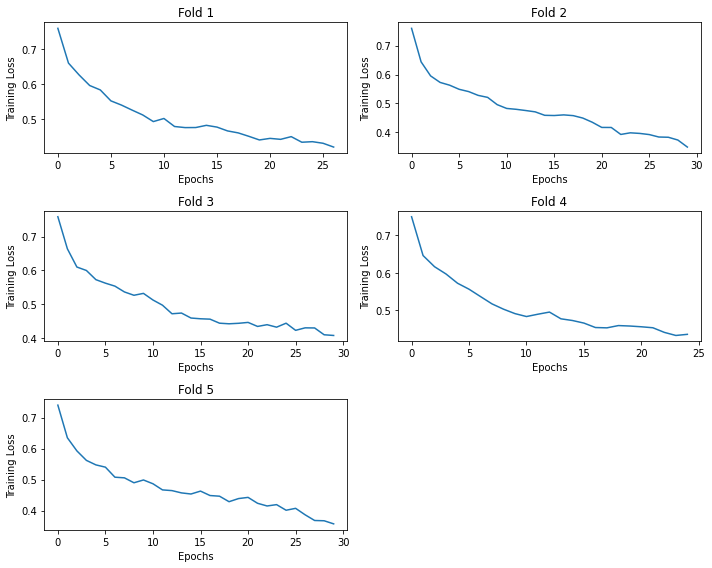

In [22]:
f, axs = plt.subplots(3, 2, figsize=(10, 8))

for fold, ax in zip(range(5), axs.flatten()):
    fold_history = history[f"fold_{fold}"]
    
    ax.set_title(f"Fold {fold + 1}")
    ax.plot(fold_history["loss"])
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Training Loss")
    
f.delaxes(axs.flatten()[-1])
plt.tight_layout()

## Accuracy Curve

We will visualize the accuracy curve.

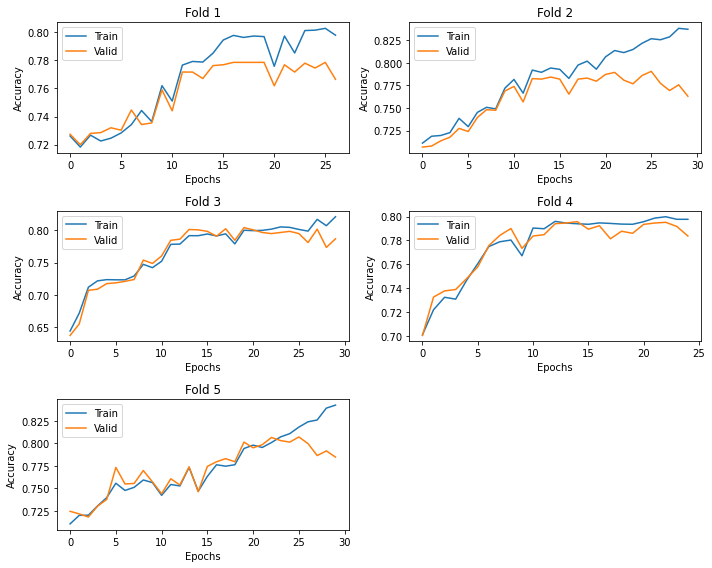

In [23]:
f, axs = plt.subplots(3, 2, figsize=(10, 8))

for fold, ax in zip(range(5), axs.flatten()):
    fold_history = history[f"fold_{fold}"]
    
    ax.set_title(f"Fold {fold + 1}")
    ax.plot(fold_history["train_accuracy"], label="Train")
    ax.plot(fold_history["valid_accuracy"], label="Valid")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Accuracy")
    ax.legend()
    
f.delaxes(axs.flatten()[-1])
plt.tight_layout()

## Explainability

Below, we will visualize the explainability data. The y-axis is the sample number and the x-axis is the position of the feature in the dataset. A lighter color implies that that feature contributed more to the results for that sample.

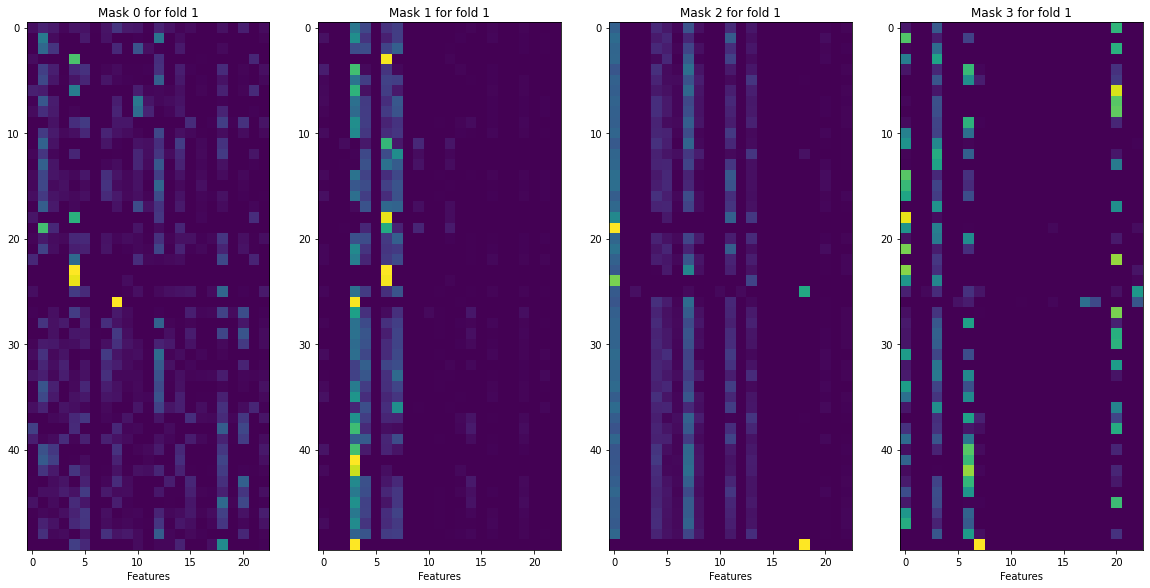

In [24]:
n_steps = params["n_steps"]
# Change this number to see other folds
fold = 0

explain_matrix, masks = explains[f"fold_{0}"]

fig, axs = plt.subplots(1, n_steps, figsize=(20, 20))

for i in range(n_steps):
    axs[i].imshow(masks[i][:50])
    axs[i].set_xlabel("Features")
    axs[i].set_label("Samples")
    axs[i].set_title(f"Mask {i} for fold {fold + 1}")

# Submission

In [25]:
submission = results[["PassengerId", "preds"]]
submission = submission.rename(columns={"preds": "Transported"})
submission["Transported"] = submission["Transported"] >= 0.5
submission.head()

,PassengerId,Transported
test_0,0013_01,True
test_1,0018_01,False
test_2,0019_01,True
test_3,0021_01,True
test_4,0023_01,True


In [26]:
submission["Transported"].value_counts()

True     2299
False    1978
Name: Transported, dtype: int64

In [27]:
submission.to_csv("submission.csv", index=False)

# Conclusion

In this notebook, we explored how TabNet coupled with Optuna can be used to achieve good performance on the Spaceship Titanic dataset.

# References


<a id="#ref1">[1]</a> Sercan O. Arık; and Tomas Pfister. 2019. [TabNet: Attentive Interpretable Tabular Learning](https://arxiv.org/pdf/1908.07442v5.pdf). Google Cloud AI.